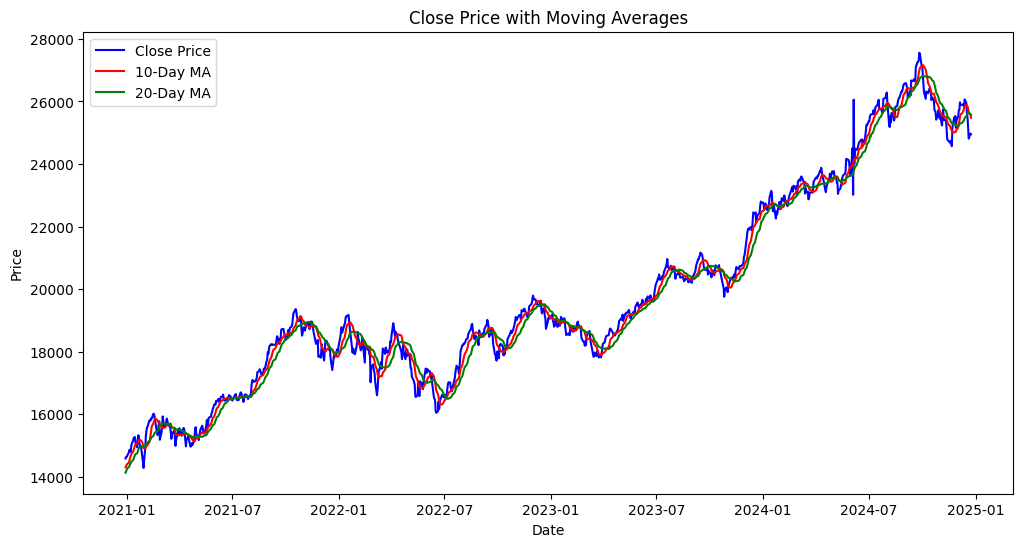

X_train shape: (790, 1, 10)
X_test shape: (198, 1, 10)
y_train shape: (790,)
y_test shape: (198,)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Load Data
data = pd.read_csv('/Users/suryanshu/Downloads/SPBSS5IP_01122020_25122024.csv', parse_dates=['Date'])
data.set_index('Date', inplace=True)

# 2. Feature Engineering
# Moving Averages
data['MA_10'] = data['Close'].rolling(window=10).mean()
data['MA_20'] = data['Close'].rolling(window=20).mean()

# Daily Returns
data['Daily_Return'] = data['Close'].pct_change()

# Volatility (10-day rolling standard deviation)
data['Volatility'] = data['Close'].rolling(window=10).std()

# Lag Features
data['Lag_1'] = data['Close'].shift(1)
data['Lag_2'] = data['Close'].shift(2)

# Drop rows with NaN values due to rolling and shifting
data.dropna(inplace=True)

# 3. Plotting (Optional, for visualization)
# Plot Close Price with Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.plot(data['MA_10'], label='10-Day MA', color='red')
plt.plot(data['MA_20'], label='20-Day MA', color='green')
plt.title('Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# 4. Data Preparation
# Select features and target
features = ['Open', 'High', 'Low', 'Close', 'MA_10', 'MA_20', 'Daily_Return', 'Volatility', 'Lag_1', 'Lag_2']
X = data[features]
y = data['Close']  # Target variable

# Scale the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, shuffle=False)

# Reshape for LSTM (if needed for time-series modeling)
X_train_reshaped = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Output data shapes
print("X_train shape:", X_train_reshaped.shape)
print("X_test shape:", X_test_reshaped.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

In [ ]:
import joblib

# Save Random Forest model
joblib.dump(rf_model, 'rf_model.pkl')

# Save LightGBM model
joblib.dump(lgb_model, 'lgb_model.pkl')

In [5]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

# Load and Preprocess Data
data = pd.read_csv('/Users/suryanshu/Downloads/SPBSS5IP_01122020_25122024.csv', parse_dates=['Date'])
data.set_index('Date', inplace=True)

# Feature Engineering
data['MA_10'] = data['Close'].rolling(window=10).mean()
data['MA_20'] = data['Close'].rolling(window=20).mean()
data['Daily_Return'] = data['Close'].pct_change()
data['Volatility'] = data['Close'].rolling(window=10).std()
data['Lag_1'] = data['Close'].shift(1)
data['Lag_2'] = data['Close'].shift(2)
data.dropna(inplace=True)

# Prepare Features and Target
features = ['Open', 'High', 'Low', 'Close', 'MA_10', 'MA_20', 'Daily_Return', 'Volatility', 'Lag_1', 'Lag_2']
X = data[features]
y = data['Close']

# Scale Features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
train_size = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y.values[:train_size], y.values[train_size:]

# --- Random Forest Model Training ---
print("\nTraining Random Forest Model...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate Random Forest Model
rf_predictions = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"Random Forest RMSE: {rf_rmse}")

# --- XGBoost Model Training ---
print("\nTraining XGBoost Model...")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Evaluate XGBoost Model
xgb_predictions = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
print(f"XGBoost RMSE: {xgb_rmse}")

# --- Visualization ---
plt.figure(figsize=(14, 7))
plt.plot(y_test, label='Actual Prices', color='blue')
plt.plot(rf_predictions, label='Random Forest Predictions', color='orange')
plt.plot(xgb_predictions, label='XGBoost Predictions', color='green')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# --- Metrics Summary ---
print("\nModel Evaluation Metrics:")
print(f"Random Forest RMSE: {rf_rmse}")
print(f"XGBoost RMSE: {xgb_rmse}")

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <BBC4A126-D15A-3802-AD26-108872BA781A> /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/O